# Block 17 — Time Series: Inferring State & Sequence
### Advanced Machine Learning — M&T Bank

**Dataset:** `macro_vix_monthly.csv` — the CBOE VIX (equity market volatility index), monthly average, January 1990
through July 2026 (439 months). Real data, sourced from CBOE via a public mirror. New topic: every block so far
has treated each row as independent. Today, order matters — this month's value depends on last month's.


## Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

# Paste the raw GitHub URL for macro_vix_monthly.csv below, then remove the leading '#':
# vix = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";", parse_dates=["date"]).set_index("date")
print(vix.shape)
vix.head(3)


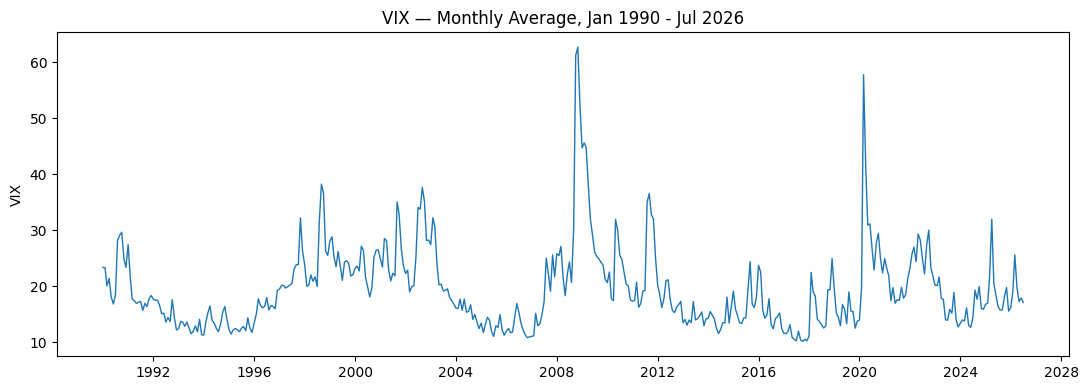

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vix.index, vix["vix_close"], linewidth=1)
ax.set_title("VIX — Monthly Average, Jan 1990 - Jul 2026")
ax.set_ylabel("VIX")
plt.tight_layout()
plt.savefig("block17_vix_series.png", dpi=110)
plt.show()


**No trend a linear model would find useful, no calendar seasonality — but clear structure anyway.** Volatility
spikes (2008, 2020, and others) and then decays back toward a baseline. That decay pattern is itself the signal:
today's value carries information about tomorrow's, in a way a single row never could on its own.


## 1. Is This Series Stationary?

Most time-series tools assume the statistical properties (mean, variance) don't drift over the series. The
Augmented Dickey-Fuller test checks this formally — the null hypothesis is that the series is *non-stationary*
(has a unit root / a trend that wanders).


In [3]:
adf_result = adfuller(vix["vix_close"])
print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.6f}")
print(f"Critical values: {adf_result[4]}")


ADF statistic: -5.2521
p-value:       0.000007
Critical values: {'1%': np.float64(-3.445437655635993), '5%': np.float64(-2.8681918844944785), '10%': np.float64(-2.5703132171113543)}


**p-value comes back far below 0.05 — we reject the null and treat the series as stationary.** That matches the
plot: VIX oscillates around a long-run level rather than trending away from it. This will matter directly in
Block 18 — ARIMA's "I" (integrated) term exists specifically to handle series that fail this test; this one won't
need differencing.


## 2. Decomposition — Trend, Seasonal, Residual

A standard first look at any time series: split it into a slow-moving trend, a repeating seasonal pattern, and
whatever's left over.


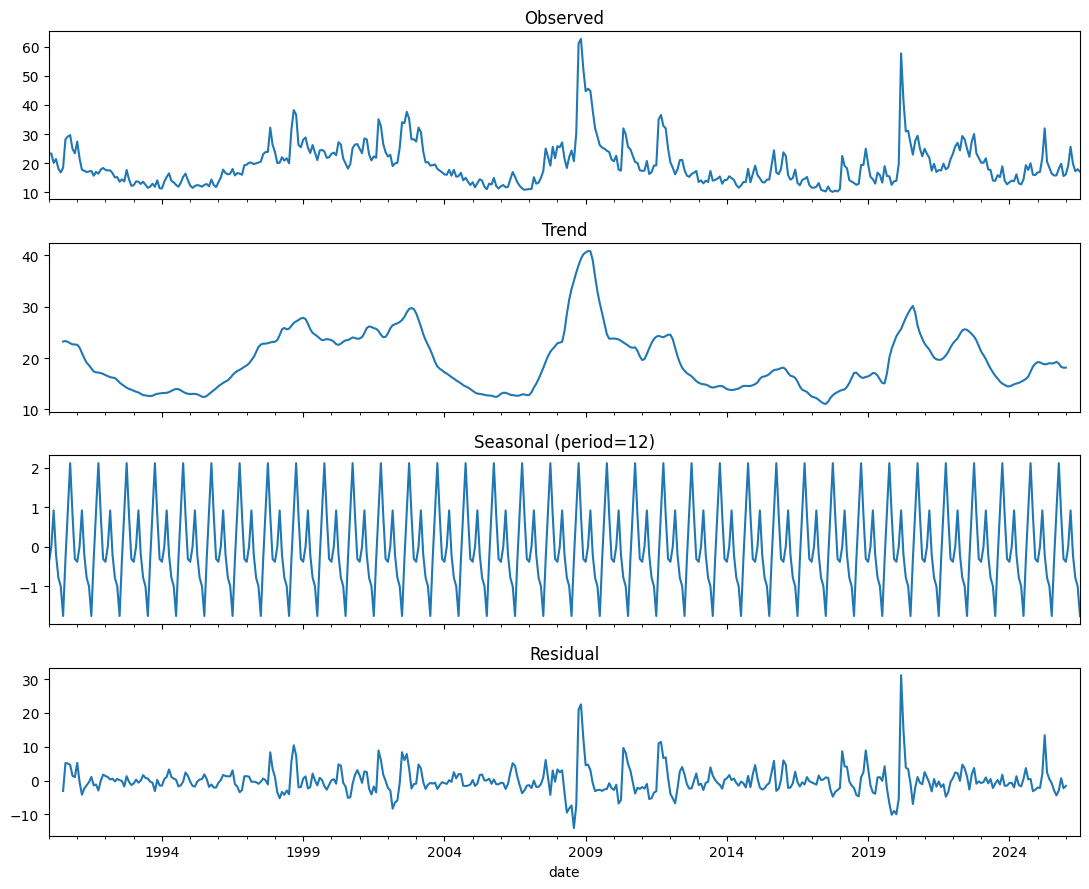

Seasonal component range: [-1.754, 2.117]
Trend component range:    [11.07, 40.83]


In [4]:
decomp = seasonal_decompose(vix["vix_close"], model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observed")
decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Seasonal (period=12)")
decomp.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.savefig("block17_decomposition.png", dpi=110)
plt.show()

print(f"Seasonal component range: [{decomp.seasonal.min():.3f}, {decomp.seasonal.max():.3f}]")
print(f"Trend component range:    [{decomp.trend.min():.2f}, {decomp.trend.max():.2f}]")


**The seasonal component stays within about ±2 VIX points next to trend swings that range over roughly 30
points — there's no meaningful calendar-month effect on market volatility worth building a model around, which
is exactly what should be true.** The trend line is really just a smoothed version of the crisis-and-recovery
pattern already visible in the raw plot. Decomposition is a good habit to run on any new series, even when — as
here — the honest answer is "no real seasonality." That's a finding, not a failure of the tool.


## 3. Autocorrelation — What "State" Means Here

If this month's value is informative about next month's, that shows up as autocorrelation: the correlation
between the series and a lagged copy of itself.


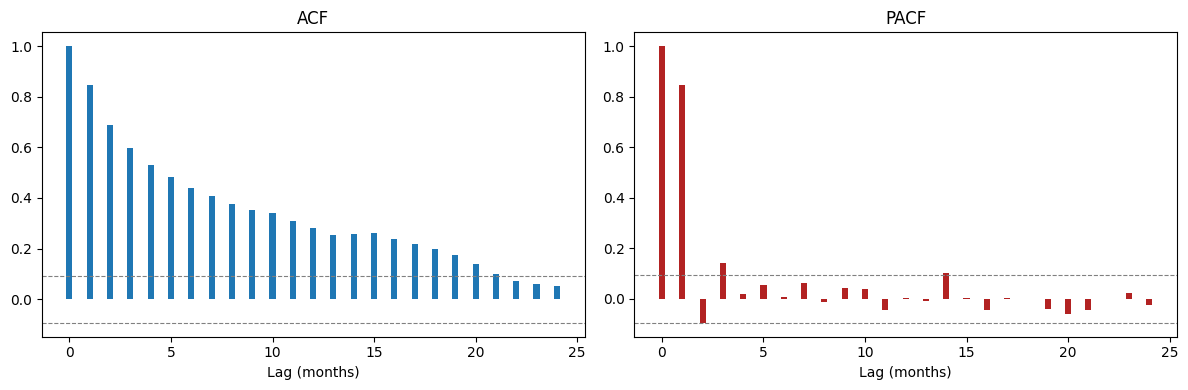

ACF lag 1:  0.846
ACF lag 12: 0.280
PACF lag 1: 0.848
PACF lag 2: -0.095


In [5]:
n_lags = 24
acf_vals = acf(vix["vix_close"], nlags=n_lags)
pacf_vals = pacf(vix["vix_close"], nlags=n_lags)
conf = 1.96 / np.sqrt(len(vix))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(n_lags + 1), acf_vals, width=0.3)
axes[0].axhline(conf, color="grey", linestyle="--", linewidth=0.8)
axes[0].axhline(-conf, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title("ACF")
axes[0].set_xlabel("Lag (months)")

axes[1].bar(range(n_lags + 1), pacf_vals, width=0.3, color="firebrick")
axes[1].axhline(conf, color="grey", linestyle="--", linewidth=0.8)
axes[1].axhline(-conf, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("PACF")
axes[1].set_xlabel("Lag (months)")
plt.tight_layout()
plt.savefig("block17_acf_pacf.png", dpi=110)
plt.show()

print(f"ACF lag 1:  {acf_vals[1]:.3f}")
print(f"ACF lag 12: {acf_vals[12]:.3f}")
print(f"PACF lag 1: {pacf_vals[1]:.3f}")
print(f"PACF lag 2: {pacf_vals[2]:.3f}")


**Lag-1 autocorrelation is strong (well above the confidence band) and decays gradually across lags — the
classic signature of an autoregressive process.** The PACF, which strips out the indirect effect of
in-between lags, cuts off sharply after lag 1-2: most of what lag 3, 4, 5... explain about today is really just
relayed through lag 1. That PACF cutoff is the diagnostic Block 18 will use directly to choose an AR order for
ARIMA.


## 4. Partitioning a Time Series — Chronological, Not Random

Block 5 and Block 10 both established the same rule from different angles: partition before you look, and do it
the same way you'll be asked to predict in production. For an independent-rows dataset, that meant a random
split. **Here, a random split would be actively wrong** — training on some months from 2020 and testing on other
months from 2015 would let the model see the future before predicting the past. The split has to be
chronological: train on the earlier stretch, test on the later stretch, in time order.


Train: 1990-01-01 to 2019-03-01  (351 months)
Test:  2019-04-01 to 2026-07-01  (88 months)


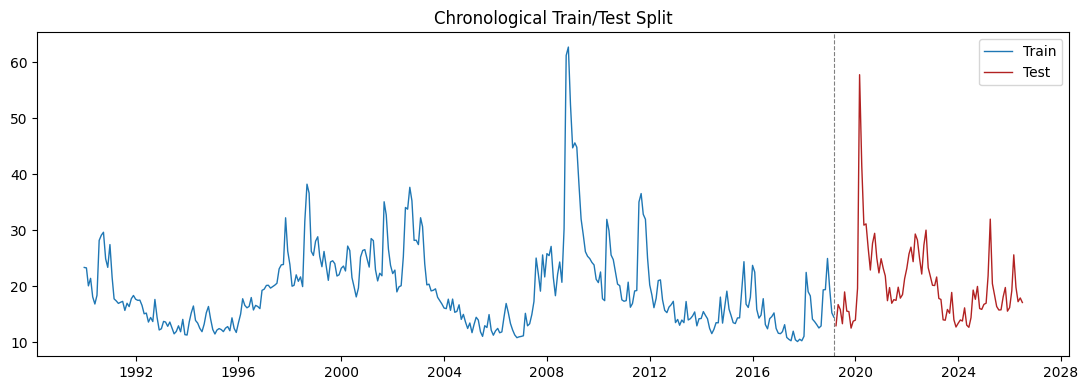

In [6]:
split_idx = int(len(vix) * 0.8)
train, test = vix.iloc[:split_idx], vix.iloc[split_idx:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()}  ({len(train)} months)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()}  ({len(test)} months)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train.index, train["vix_close"], label="Train", linewidth=1)
ax.plot(test.index, test["vix_close"], label="Test", linewidth=1, color="firebrick")
ax.axvline(train.index.max(), color="grey", linestyle="--", linewidth=0.8)
ax.legend()
ax.set_title("Chronological Train/Test Split")
plt.tight_layout()
plt.savefig("block17_split.png", dpi=110)
plt.show()


## 5. A Baseline Worth Beating: the Naive Forecast

Before any model, set the bar. The simplest possible time-series forecast is "next month equals this month" —
the naive (persistence) forecast. Any real model needs to beat this, or it isn't earning its complexity, exactly
the same discipline Block 12 applied to Random Forest against the Block 6 logistic benchmark.


In [7]:
naive_pred = test["vix_close"].shift(1)
naive_pred.iloc[0] = train["vix_close"].iloc[-1]

lag1_actual = test["vix_close"].values
naive_mae = np.mean(np.abs(lag1_actual - naive_pred.values))
naive_rmse = np.sqrt(np.mean((lag1_actual - naive_pred.values) ** 2))
print(f"Naive forecast MAE:  {naive_mae:.3f}")
print(f"Naive forecast RMSE: {naive_rmse:.3f}")


Naive forecast MAE:  3.192
Naive forecast RMSE: 5.600


In [8]:
# A one-step-better baseline: simple lag-1 linear regression, fit on train only
from sklearn.linear_model import LinearRegression

train_lagged = pd.DataFrame({"y": train["vix_close"].values[1:], "lag1": train["vix_close"].values[:-1]})
lr = LinearRegression().fit(train_lagged[["lag1"]], train_lagged["y"])

full = pd.concat([train, test])["vix_close"]
test_lag1 = full.shift(1).loc[test.index]
lr_pred = lr.predict(test_lag1.values.reshape(-1, 1))

lr_mae = np.mean(np.abs(lag1_actual - lr_pred))
lr_rmse = np.sqrt(np.mean((lag1_actual - lr_pred) ** 2))
print(f"Lag-1 linear regression MAE:  {lr_mae:.3f}")
print(f"Lag-1 linear regression RMSE: {lr_rmse:.3f}")
print(f"Fitted: y = {lr.intercept_:.3f} + {lr.coef_[0]:.3f} * lag1")


Lag-1 linear regression MAE:  2.996
Lag-1 linear regression RMSE: 5.326
Fitted: y = 2.190 + 0.885 * lag1


**The fitted lag-1 regression barely beats the naive forecast, and its slope coefficient sits close to 1** —
which is itself informative: it confirms the process is close to a random walk with mean reversion, not one where
a plain linear lag relationship has much slack left to exploit. That's precisely the kind of series ARIMA is
built for, and precisely why Block 18 will need more than a single lag term to do meaningfully better than what's
sitting right here.


## Recap

- Established the series is stationary (ADF test) — no differencing needed going in
- Decomposition confirmed no meaningful seasonality — the story here is trend/shock, not calendar effects
- ACF/PACF showed strong, gradually-decaying autocorrelation with a sharp PACF cutoff near lag 1-2 — an AR
  signature
- Partitioned chronologically, not randomly, and set a naive-forecast baseline (RMSE above) for Block 18 to beat

**Next: ARIMA** — a model built directly on the AR order the PACF just suggested, plus the "I" and "MA" terms for
series that need them.
